# 04 - Análisis Final y Visualizaciones

Este notebook realiza:
- Agregación de datos por mes
- Análisis y estadísticas por categoría
- Visualizaciones de resultados
- Exportación de reportes

## Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.transform import (
    aggregate_by_month,
    create_category_summary,
    create_category_measurement_summary,
    detect_outliers_iqr,
    detect_outliers_zscore,
    get_anomaly_report,
    detect_price_anomalies
)

# Configurar visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (20, 10)

## Cargar datos procesados

In [3]:
# Cargar datos transformados del paso anterior
df = pd.read_csv('../data/processed/data_transformada.csv')

# Obtener columnas de fecha (excluyendo otras numéricas)
cols_fecha = [col for col in df.select_dtypes(include='number').columns if col not in ['orden', 'precio_promedio']]

print(f"Datos procesados listos: {df.shape}")
print(df.head())


Datos procesados listos: (207, 144)
   orden                  nombre unidad_de_medida  2023-08-07 00:00:00  \
0      1   Aceite de soya Crisol     Galón 128 Oz           708.237500   
1      2  Aceite de soya La Joya     Galón 128 Oz           702.385000   
2      3         Aceite el Gallo     Galón 128 Oz           674.400000   
3      4         Aceite Diamante     Galón 128 Oz           741.316667   
4      5         Aceite Manicero     Galón 128 Oz           817.981250   

   2023-08-14 00:00:00  2023-08-21 00:00:00  2023-08-28 00:00:00  \
0           702.900000           706.154167           705.400000   
1           701.280000           669.981250           701.280000   
2           668.590000           671.316667           668.590000   
3           741.633333           748.300000           754.966667   
4           820.264286           813.971429           813.971429   

   2023-09-04 00:00:00  2023-09-11 00:00:00  2023-09-19 00:00:00  ...  \
0           708.404167           704.

## 1. Agregar datos por mes

In [4]:
df_mensual = aggregate_by_month(df, cols_fecha)
print(f"Datos mensuales: {df_mensual.shape}")
print(f"Período: {df_mensual.columns[-5:].tolist()}")
print("\nEjemplo:")
print(df_mensual[['nombre', 'categoria'] + df_mensual.columns[-3:].tolist()].head())

Datos mensuales: (207, 37)
Período: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03']

Ejemplo:
                   nombre categoria     2026-01     2026-02     2026-03
0   Aceite de soya Crisol    Aceite  671.505808  661.531818  657.103864
1  Aceite de soya La Joya    Aceite  605.096007  609.200000  613.083333
2         Aceite el Gallo    Aceite  644.643571  650.342321  661.359167
3         Aceite Diamante    Aceite  693.500000  629.000000  629.000000
4         Aceite Manicero    Aceite  750.298929  729.021429  731.273929


## 2. Resumen por categoría y unidad de medida

In [5]:
resumen = create_category_measurement_summary(df, cols_fecha)
print("\nResumen de Precios por Categoría:")
print(resumen.to_string())


Resumen de Precios por Categoría:
                                            Promedio   Mínimo   Máximo  Cantidad de Productos
categoria      unidad_de_medida                                                              
Leche en polvo Caja 1,800 G                  2114.17  2114.17  2114.17                      1
               Lata 2,269 gramo              1946.30  1946.30  1946.30                      1
               Lata 850 gramo                1808.00  1808.00  1808.00                      1
               Lata 1,600 gramo              1734.92  1545.25  1924.60                      2
               Funda 2,200 G                 1688.11  1688.11  1688.11                      1
               Funda 2,269 gramo             1680.53  1680.53  1680.53                      1
               Funda 2,500 gramo             1677.78  1677.78  1677.78                      1
Leche liquida  2 Oz/Pqte. 24 Unidad          1653.83  1653.83  1653.83                      1
Leche en polvo Funda 2,20

## 2. Resumen por categoría

In [6]:
resumen = create_category_summary(df, cols_fecha)
print("\nResumen de Precios por Categoría:")
print(resumen.to_string())


Resumen de Precios por Categoría:
                Promedio  Mínimo   Máximo  Cantidad de Productos
categoria                                                       
Leche en polvo   1063.06   79.94  2114.17                     38
Aceite            419.64   91.53   975.35                     22
Arroz             407.66  373.65   428.53                      7
Leche liquida     383.10   58.31  1653.83                     10
Huevos            232.03  201.69   247.45                      3
Lacteos           187.94   42.31   303.01                      7
Carne res         174.43  124.54   194.38                      6
Pescado           173.01   60.62   344.68                      5
Café              167.72   23.07   312.37                      2
Azúcar            164.04  152.38   175.70                      2
Pan               147.32   45.40   266.97                     10
Carne cerdo       130.17   81.56   207.25                      6
Embutidos         118.73   92.47   135.53              

## 3. Visualizaciones

### 3.1 Precio promedio por categoría

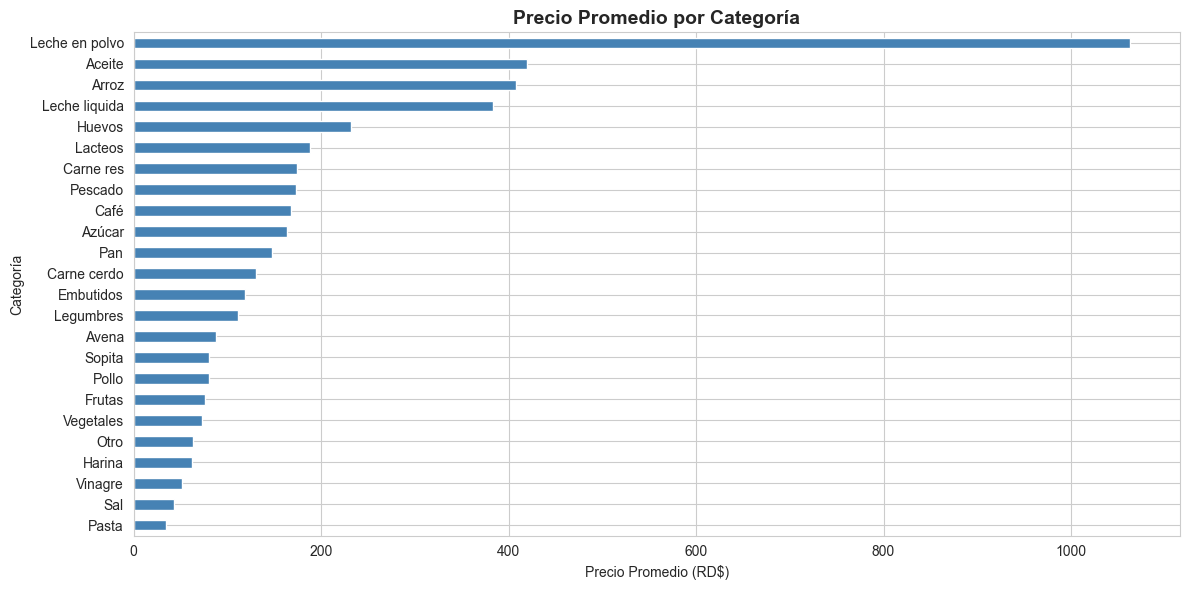

✓ Gráfico guardado


In [7]:
plt.figure(figsize=(12, 6))
resumen['Promedio'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Precio Promedio por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Precio Promedio (RD$)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.savefig('../data/processed/precio_promedio_por_categoria.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado")

### 3.2 Cantidad de productos por categoría

FileNotFoundError: [Errno 2] No such file or directory: './data/processed/cantidad_productos_por_categoria.png'

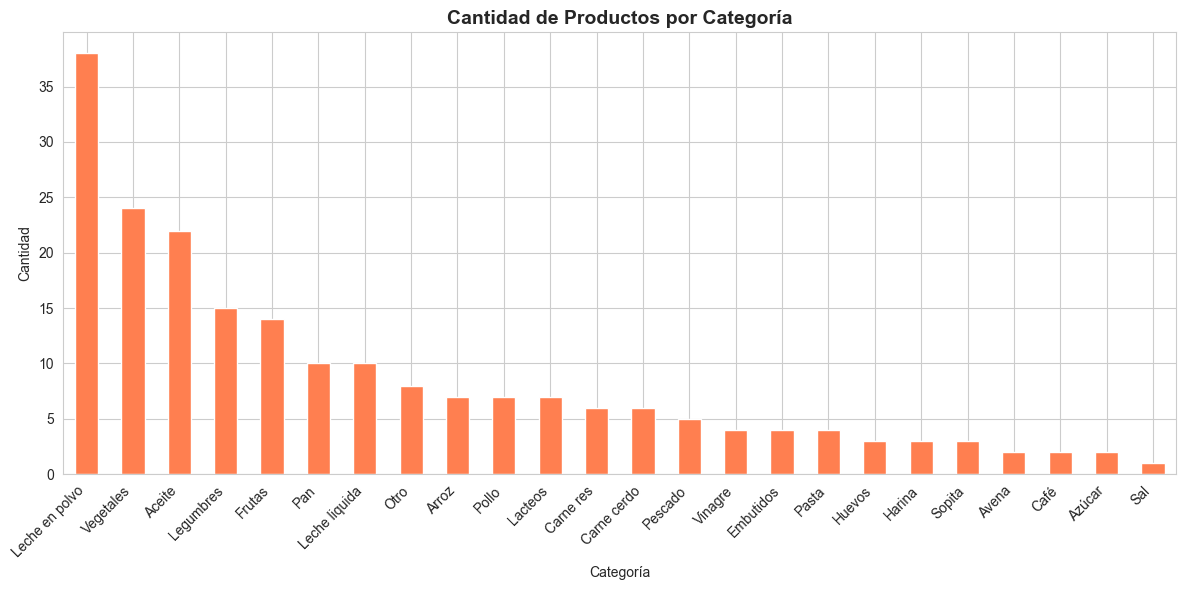

In [8]:
plt.figure(figsize=(12, 6))
resumen['Cantidad de Productos'].sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Cantidad de Productos por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./data/processed/cantidad_productos_por_categoria.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado")

### 3.3 Rango de precios (min-max) por categoría

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

categorias = resumen.index
y_pos = np.arange(len(categorias))

# Plotear rango (error bars)
ax.barh(y_pos, resumen['Promedio'], color='steelblue', alpha=0.7)
ax.errorbar(resumen['Promedio'], y_pos, 
            xerr=[resumen['Promedio'] - resumen['Mínimo'], resumen['Máximo'] - resumen['Promedio']],
            fmt='none', ecolor='red', elinewidth=2, capsize=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(categorias)
ax.set_xlabel('Precio (RD$)')
ax.set_title('Rango de Precios por Categoría (Mín-Promedio-Máx)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/rango_precios_por_categoria.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado")

## 4. Estadísticas adicionales

In [ ]:
print("\n=== ESTADÍSTICAS GENERALES ===")
print(f"Total de productos: {len(df)}")
print(f"Total de categorías: {df['categoria'].nunique()}")
print(f"Precio promedio nacional: RD$ {df['precio_promedio'].mean():.2f}")
print(f"Precio mínimo: RD$ {df['precio_promedio'].min():.2f}")
print(f"Precio máximo: RD$ {df['precio_promedio'].max():.2f}")
print(f"Desviación estándar: RD$ {df['precio_promedio'].std():.2f}")

## 5. Productos más caros y más baratos

In [ ]:
print("\n=== TOP 10 PRODUCTOS MÁS CAROS ===")
top_caros = df.nlargest(10, 'precio_promedio')[['nombre', 'categoria', 'unidad_de_medida', 'precio_promedio']]
print(top_caros.to_string(index=False))

In [ ]:
print("\n=== TOP 10 PRODUCTOS MÁS BARATOS ===")
top_baratos = df.nsmallest(10, 'precio_promedio')[['nombre', 'categoria', 'unidad_de_medida', 'precio_promedio']]
print(top_baratos.to_string(index=False))

## 6. Exportar reportes finales

In [ ]:
# Guardar datos finales
df.to_csv('./data/processed/data_completa.csv', index=False)
df_mensual.to_csv('./data/processed/data_mensual.csv', index=False)
resumen.to_csv('./data/processed/resumen_categoria.csv')

print("✓ Archivos guardados:")
print("  - data/processed/data_completa.csv")
print("  - data/processed/data_mensual.csv")
print("  - data/processed/resumen_categoria.csv")
print("  - data/processed/*.png (gráficos)")

In [ ]:

# Detectar outliers con ambos métodos
outliers_iqr = detect_outliers_iqr(df, col_price='precio_promedio', method='by_category')
outliers_zscore = detect_outliers_zscore(df, col_price='precio_promedio', threshold=3)

print("=== DETECCIÓN DE DATOS ATÍPICOS ===\n")
print(f"Outliers por IQR: {len(outliers_iqr)}")
print(f"Outliers por Z-Score: {len(outliers_zscore)}")

if len(outliers_iqr) > 0:
    print("\nTop 10 outliers por IQR:")
    print(outliers_iqr.head(10).to_string(index=False))

In [ ]:
# Exportar outliers
if len(outliers_iqr) > 0:
    outliers_iqr.to_csv('./data/processed/outliers_iqr.csv', index=False)
    print("✓ Outliers (IQR) guardados: data/processed/outliers_iqr.csv")

if len(outliers_zscore) > 0:
    outliers_zscore.to_csv('./data/processed/outliers_zscore.csv', index=False)
    print("✓ Outliers (Z-Score) guardados: data/processed/outliers_zscore.csv")

In [ ]:
# Visualizar outliers por tipo
if len(outliers_iqr) > 0:
    outliers_tipo = outliers_iqr['tipo_outlier'].value_counts()
    
    plt.figure(figsize=(10, 5))
    outliers_tipo.plot(kind='bar', color=['red', 'blue'], alpha=0.7)
    plt.title('Datos Atípicos por Tipo (IQR)', fontsize=14, fontweight='bold')
    plt.xlabel('Tipo')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('./data/processed/outliers_por_tipo.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico guardado")

NameError: name 'outliers_iqr' is not defined

In [ ]:
if len(outliers_zscore) > 0:
    print("\nTop 10 outliers por Z-Score:")
    print(outliers_zscore.head(10).to_string(index=False))

## 8. Detección de Datos Atípicos (Outliers)

Identifica productos con precios anormalmente altos o bajos comparado con su categoría.

In [ ]:

# Detectar anomalías con umbral de 40%
anomalias = detect_price_anomalies(df, cols_fecha, threshold_pct=40)

print(f"Total de anomalías detectadas: {len(anomalias)}")
print("\nPrimeras 10 anomalías:")
if len(anomalias) > 0:
    print(anomalias.head(10).to_string(index=False))
else:
    print("No hay anomalías detectadas")

In [ ]:
# Exportar anomalías para revisión manual
if len(anomalias) > 0:
    anomalias.to_csv('./data/processed/anomalias_detectadas.csv', index=False)
    print("✓ Anomalías exportadas: data/processed/anomalias_detectadas.csv")
    print("\n📋 ACCIONES RECOMENDADAS:")
    print("────────────────────────")
    print("1. Revisar el archivo 'anomalias_detectadas.csv'")
    print("2. Validar los cambios en el archivo Excel original")
    print("3. Determinar si son cambios reales o errores de digitación")
    print("4. Corregir los datos mal digitados")
    print("5. Re-ejecutar el pipeline después de correcciones")
else:
    print("✓ No se detectaron anomalías de precios")

In [ ]:
# Visualizar top 15 anomalías más severas
if len(anomalias) > 0:
    print("\n=== TOP 15 ANOMALÍAS MÁS SEVERAS (REVISAR MANUALMENTE) ===\n")
    top_anomalias = anomalias.head(15)
    for idx, row in top_anomalias.iterrows():
        print(f"{row['nombre']} ({row['categoria']})")
        print(f"  {row['periodo1']}: RD$ {row['precio1']}")
        print(f"  {row['periodo2']}: RD$ {row['precio2']}")
        print(f"  ⚠️  Cambio: {row['cambio_pct']}%\n")

NameError: name 'anomalias' is not defined

In [ ]:
# Visualizar anomalías por categoría
if len(anomalias) > 0:
    anomalias_por_cat = anomalias.groupby('categoria').size().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    anomalias_por_cat.plot(kind='bar', color='red', alpha=0.7)
    plt.title('Anomalías de Precios por Categoría (Cambio >40%)', fontsize=14, fontweight='bold')
    plt.xlabel('Categoría')
    plt.ylabel('Cantidad de Anomalías')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('./data/processed/anomalias_por_categoria.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico guardado")
else:
    print("No hay anomalías para visualizar")

In [ ]:
# Generar reporte de anomalías
reporte = get_anomaly_report(df, cols_fecha, threshold_pct=40)

print("\n=== REPORTE DE ANOMALÍAS ===")
print(f"Total de cambios anómalos: {reporte['total_anomalias']}")
print(f"Productos afectados: {reporte['productos_afectados']}")

if len(reporte['anomalias_por_categoria']) > 0:
    print("\nAnomalías por categoría:")
    print(reporte['anomalias_por_categoria'].to_string())
else:
    print("\nNo hay anomalías detectadas")

## 7. Detección de Anomalías de Precios

Identifica cambios sospechosos entre períodos consecutivos que podrían indicar errores de digitación o datos inconsistentes.